## 1. Import Library

In [1]:
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

## 2. Eksplorasi & Visualisasi Dataset

In [2]:
dataset_path = './dataset/'
distribusi_kelas = {}
total_keseluruhan = 0

for nama_kelas in sorted(os.listdir(dataset_path)):
    folder_kelas = os.path.join(dataset_path, nama_kelas)
    if os.path.isdir(folder_kelas):
        jumlah_gambar = len([f for f in os.listdir(folder_kelas) if not f.startswith('.')])
        distribusi_kelas[nama_kelas] = jumlah_gambar
        total_keseluruhan += jumlah_gambar

print(f"Total kelas: {len(distribusi_kelas)}")
print(f"Total keseluruhan gambar: {total_keseluruhan}")
print(f"Rata-rata gambar per kelas: {total_keseluruhan // len(distribusi_kelas)}")
print(f"Kelas terkecil: {min(distribusi_kelas.values())} gambar")
print(f"Kelas terbesar: {max(distribusi_kelas.values())} gambar")

Total kelas: 44
Total keseluruhan gambar: 53616
Rata-rata gambar per kelas: 1218
Kelas terkecil: 51 gambar
Kelas terbesar: 6140 gambar


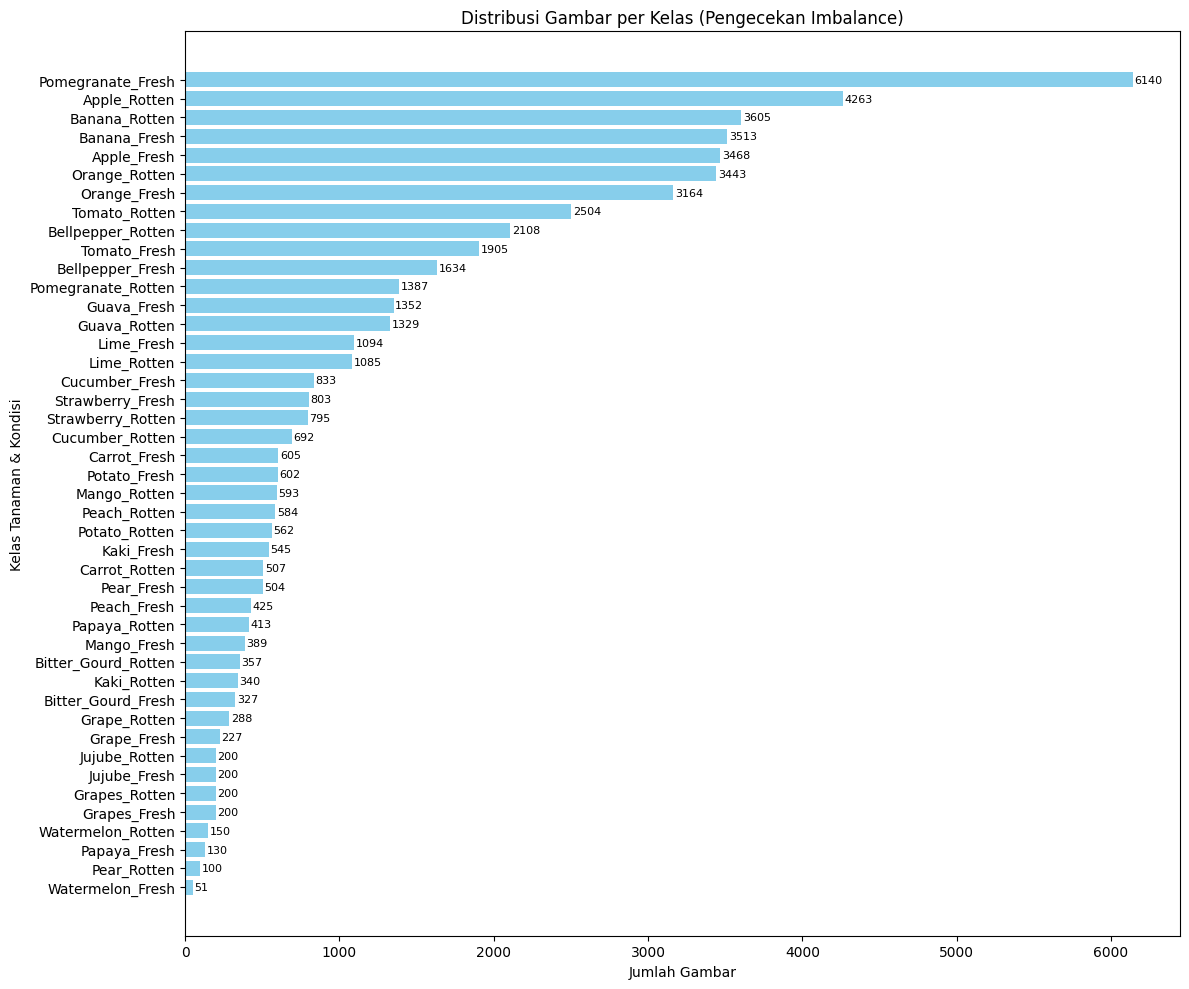

In [3]:
# Visualisasi distribusi kelas
kelas_terurut = sorted(distribusi_kelas.items(), key=lambda x: x[1], reverse=False)
nama_kelas = [item[0] for item in kelas_terurut]
jumlah = [item[1] for item in kelas_terurut]

plt.figure(figsize=(12, 10))
bars = plt.barh(nama_kelas, jumlah, color='skyblue')

for index, value in enumerate(jumlah):
    plt.text(value + 10, index, str(value), va='center', fontsize=8)

plt.xlabel('Jumlah Gambar')
plt.ylabel('Kelas Tanaman & Kondisi')
plt.title('Distribusi Gambar per Kelas (Pengecekan Imbalance)')
plt.tight_layout()
plt.show()

In [4]:
# Statistik Ukuran Gambar Asli
all_width = []
all_height = []
ekstensi_valid = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

for nama_kelas in sorted(os.listdir(dataset_path)):
    folder_kelas = os.path.join(dataset_path, nama_kelas)
    if not os.path.isdir(folder_kelas):
        continue
    for nama_file in os.listdir(folder_kelas):
        ext = os.path.splitext(nama_file)[1].lower()
        if ext not in ekstensi_valid:
            continue
        path_gambar = os.path.join(folder_kelas, nama_file)
        try:
            with Image.open(path_gambar) as img:
                w, h = img.size  # PIL: size = (width, height)
                all_width.append(w)
                all_height.append(h)
        except Exception:
            pass  # skip gambar corrupt

all_width  = np.array(all_width)
all_height = np.array(all_height)

print(f"Total gambar terbaca : {len(all_width)}")
print(f"\nStatistik Width (px)")
print(f"  Min    : {all_width.min()}")
print(f"  Max    : {all_width.max()}")
print(f"  Mean   : {all_width.mean():.1f}")
print(f"  Median : {np.median(all_width):.1f}")
print(f"\nStatistik Height (px)")
print(f"  Min    : {all_height.min()}")
print(f"  Max    : {all_height.max()}")
print(f"  Mean   : {all_height.mean():.1f}")
print(f"  Median : {np.median(all_height):.1f}")

rasio = all_width / all_height
gambar_square = np.sum(rasio == 1.0)
print(f"\nGambar rasio 1:1 (square) : {gambar_square} ({gambar_square/len(rasio)*100:.1f}%)")

Total gambar terbaca : 53616

Statistik Width (px)
  Min    : 80
  Max    : 8000
  Mean   : 616.0
  Median : 298.0

Statistik Height (px)
  Min    : 95
  Max    : 6000
  Mean   : 518.7
  Median : 258.0

Gambar rasio 1:1 (square) : 22841 (42.6%)


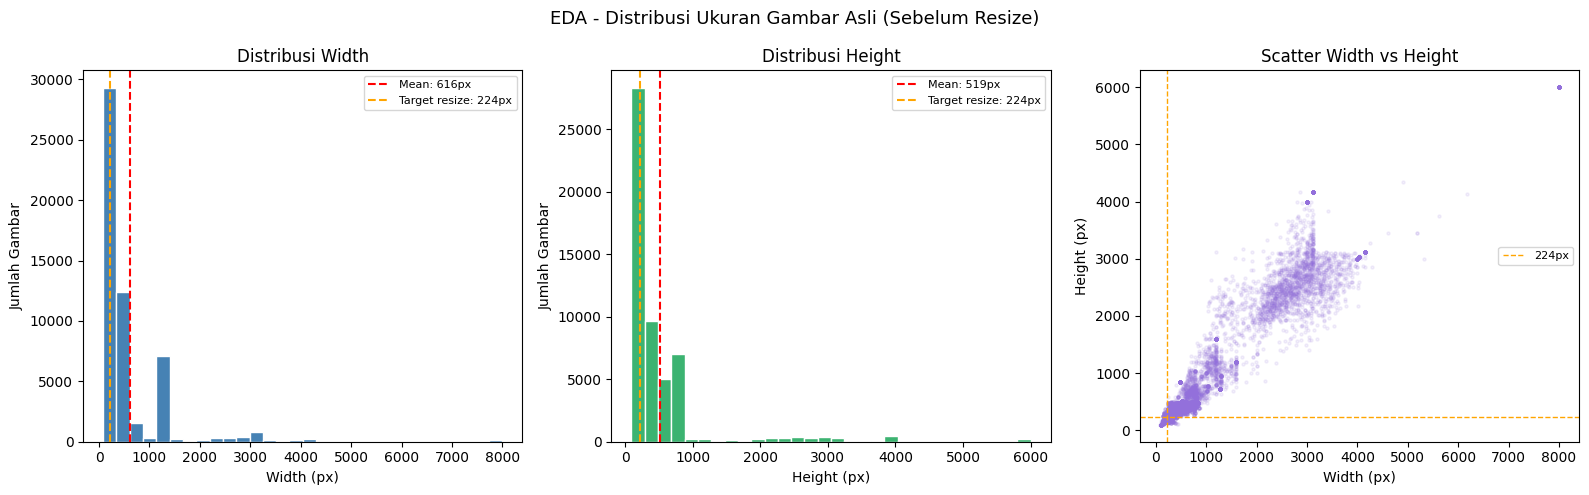

In [5]:
# Visualisasi Distribusi Ukuran Gambar Asli
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA - Distribusi Ukuran Gambar Asli (Sebelum Resize)', fontsize=13)

# Plot 1: Histogram Width
axes[0].hist(all_width, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(all_width.mean(), color='red', linestyle='--', label=f'Mean: {all_width.mean():.0f}px')
axes[0].axvline(224, color='orange', linestyle='--', label='Target resize: 224px')
axes[0].set_title('Distribusi Width')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend(fontsize=8)

# Plot 2: Histogram Height
axes[1].hist(all_height, bins=30, color='mediumseagreen', edgecolor='white')
axes[1].axvline(all_height.mean(), color='red', linestyle='--', label=f'Mean: {all_height.mean():.0f}px')
axes[1].axvline(224, color='orange', linestyle='--', label='Target resize: 224px')
axes[1].set_title('Distribusi Height')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].legend(fontsize=8)

# Plot 3: Scatter Width vs Height
axes[2].scatter(all_width, all_height, alpha=0.1, s=5, color='mediumpurple')
axes[2].axvline(224, color='orange', linestyle='--', linewidth=1, label='224px')
axes[2].axhline(224, color='orange', linestyle='--', linewidth=1)
axes[2].set_title('Scatter Width vs Height')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

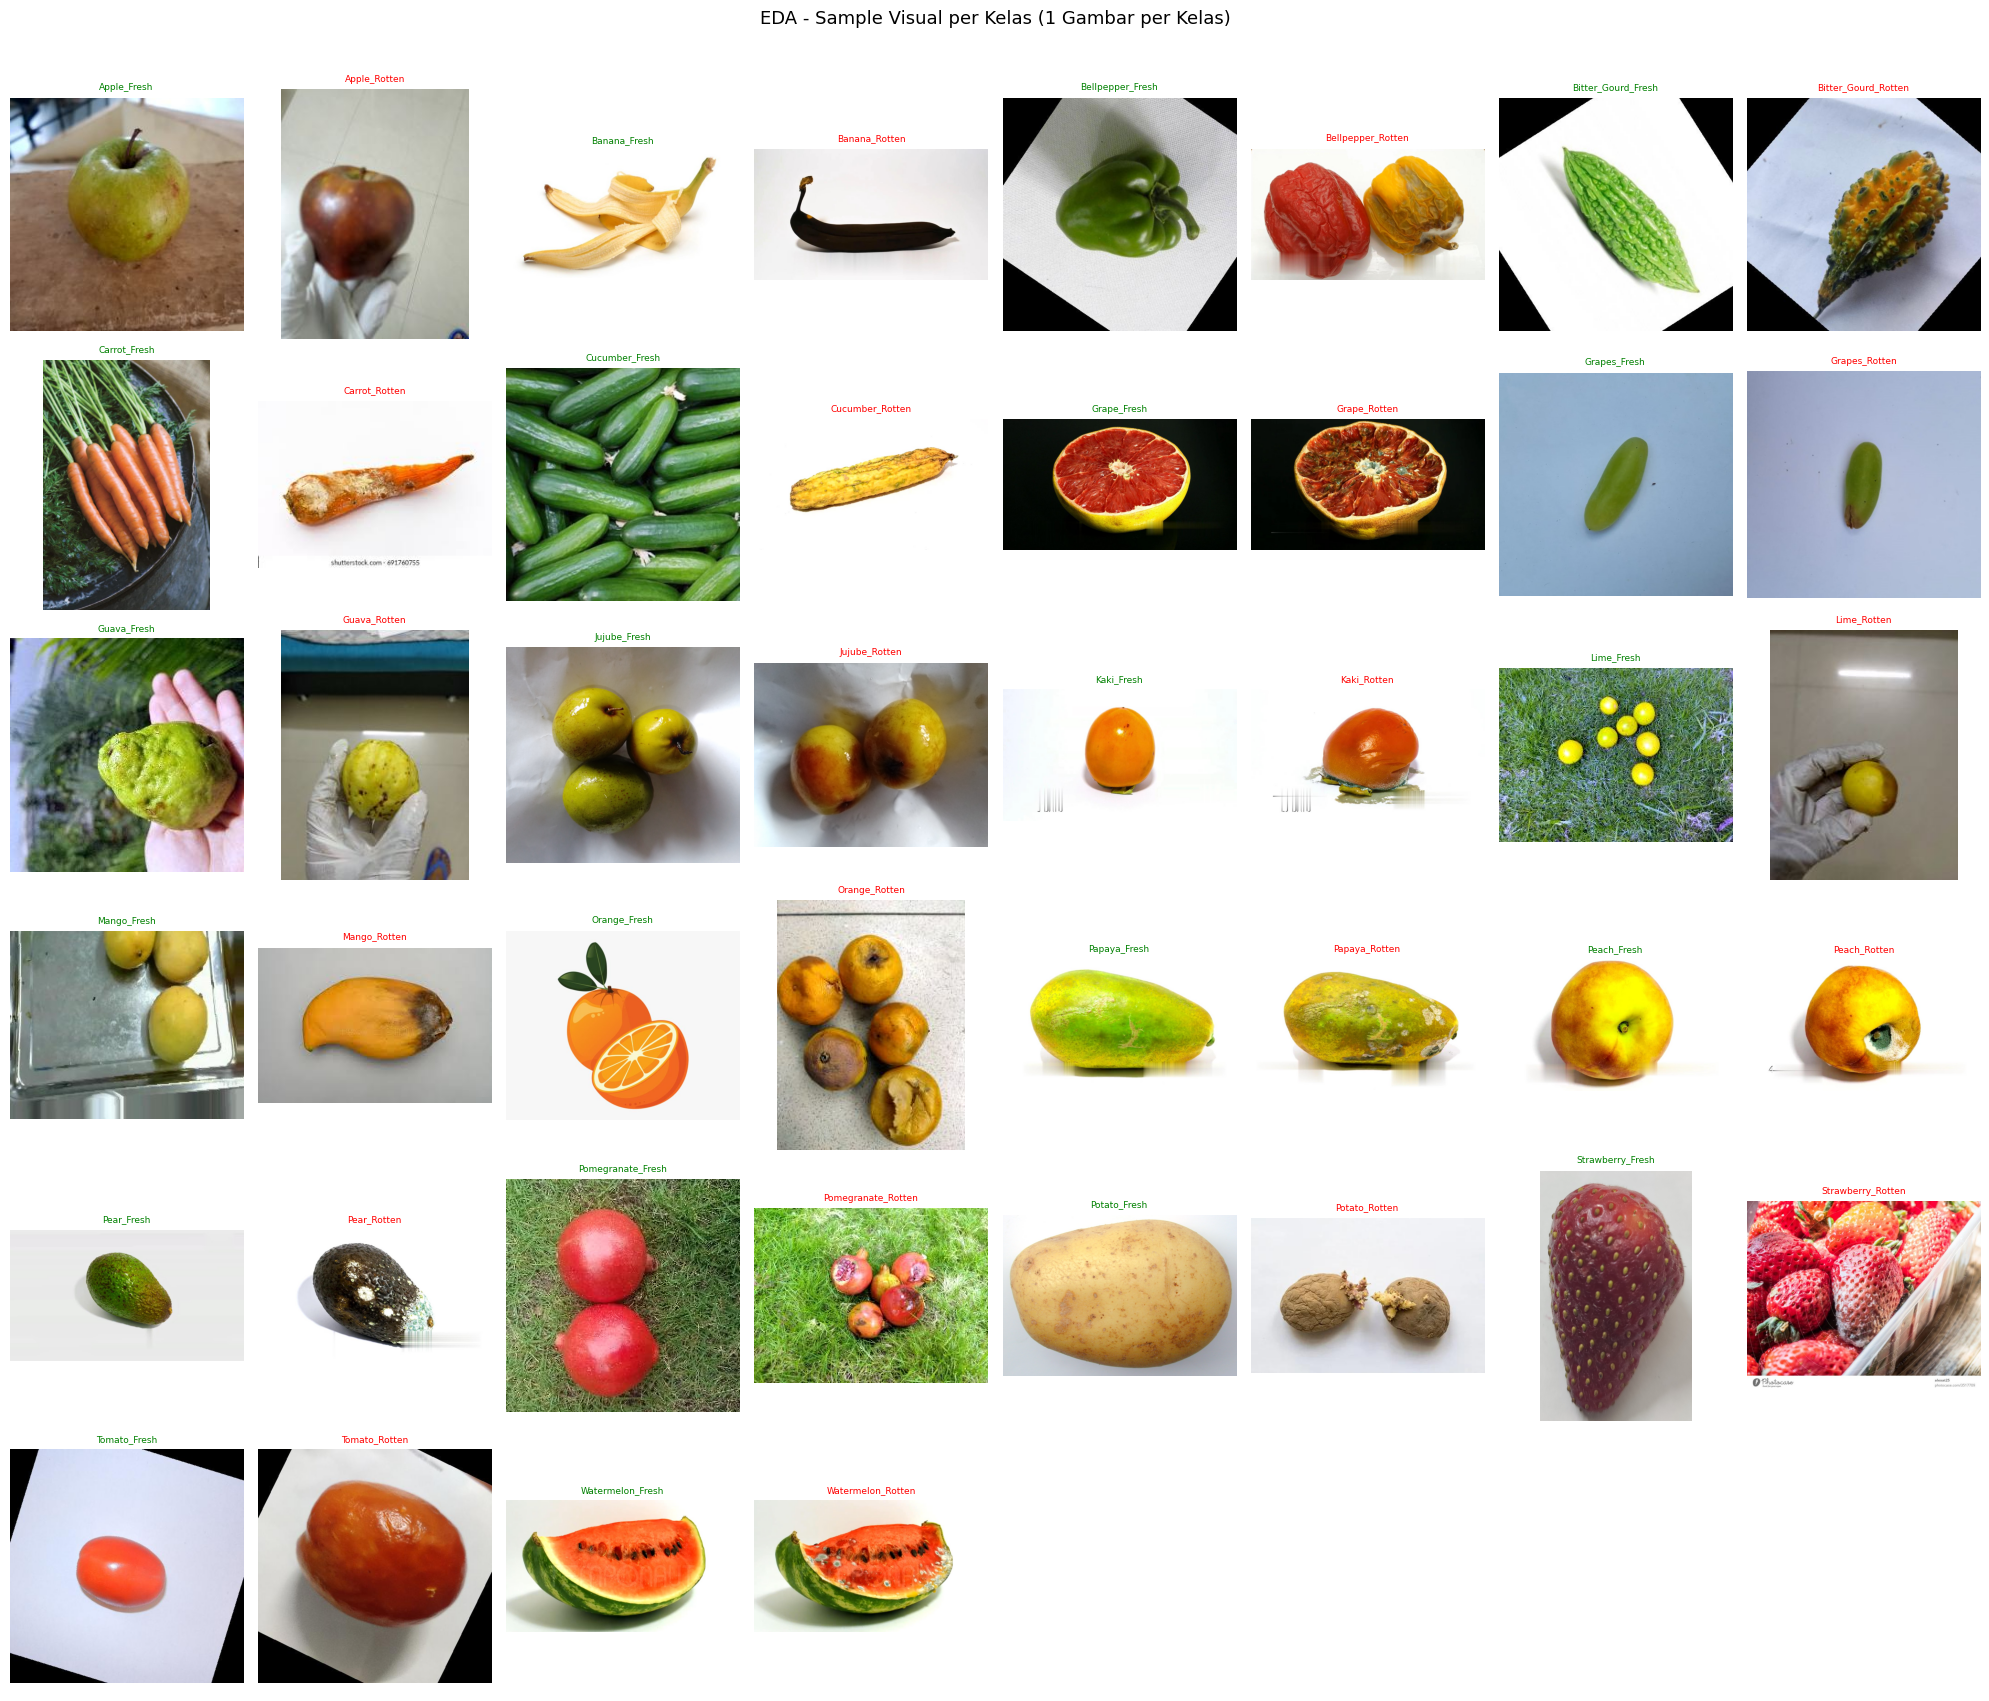

In [6]:
# Sample Visual per Kelas
all_class_names = sorted([
    k for k in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, k))
])

kolom = 8
baris = (len(all_class_names) + kolom - 1) // kolom

fig, axes = plt.subplots(baris, kolom, figsize=(20, baris * 2.8))
fig.suptitle('EDA - Sample Visual per Kelas (1 Gambar per Kelas)', fontsize=13, y=1.01)
axes = axes.flatten()

for i, nama_kelas in enumerate(all_class_names):
    folder_kelas = os.path.join(dataset_path, nama_kelas)
    file_list = [f for f in os.listdir(folder_kelas)
                 if os.path.splitext(f)[1].lower() in {'.jpg', '.jpeg', '.png'}]
    if not file_list:
        axes[i].axis('off')
        continue
    img = Image.open(os.path.join(folder_kelas, file_list[0])).convert('RGB')
    axes[i].imshow(img)
    warna = 'green' if 'Fresh' in nama_kelas else 'red'  # hijau = Fresh, merah = Rotten
    axes[i].set_title(nama_kelas, fontsize=6.5, color=warna)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Analisis Warna & Brightness per Kelas
mean_rgb_per_kelas = {}  # {nama_kelas: [mean_R, mean_G, mean_B]}

for nama_kelas in all_class_names:
    folder_kelas = os.path.join(dataset_path, nama_kelas)
    file_list = [f for f in os.listdir(folder_kelas)
                 if os.path.splitext(f)[1].lower() in {'.jpg', '.jpeg', '.png'}]

    r_vals, g_vals, b_vals = [], [], []

    for nama_file in file_list:
        try:
            img = Image.open(os.path.join(folder_kelas, nama_file)).convert('RGB')
            arr = np.array(img, dtype=np.float32)  # shape: (H, W, 3)
            r_vals.append(arr[:, :, 0].mean())
            g_vals.append(arr[:, :, 1].mean())
            b_vals.append(arr[:, :, 2].mean())
        except Exception:
            pass

    mean_rgb_per_kelas[nama_kelas] = [
        np.mean(r_vals),
        np.mean(g_vals),
        np.mean(b_vals)
    ]

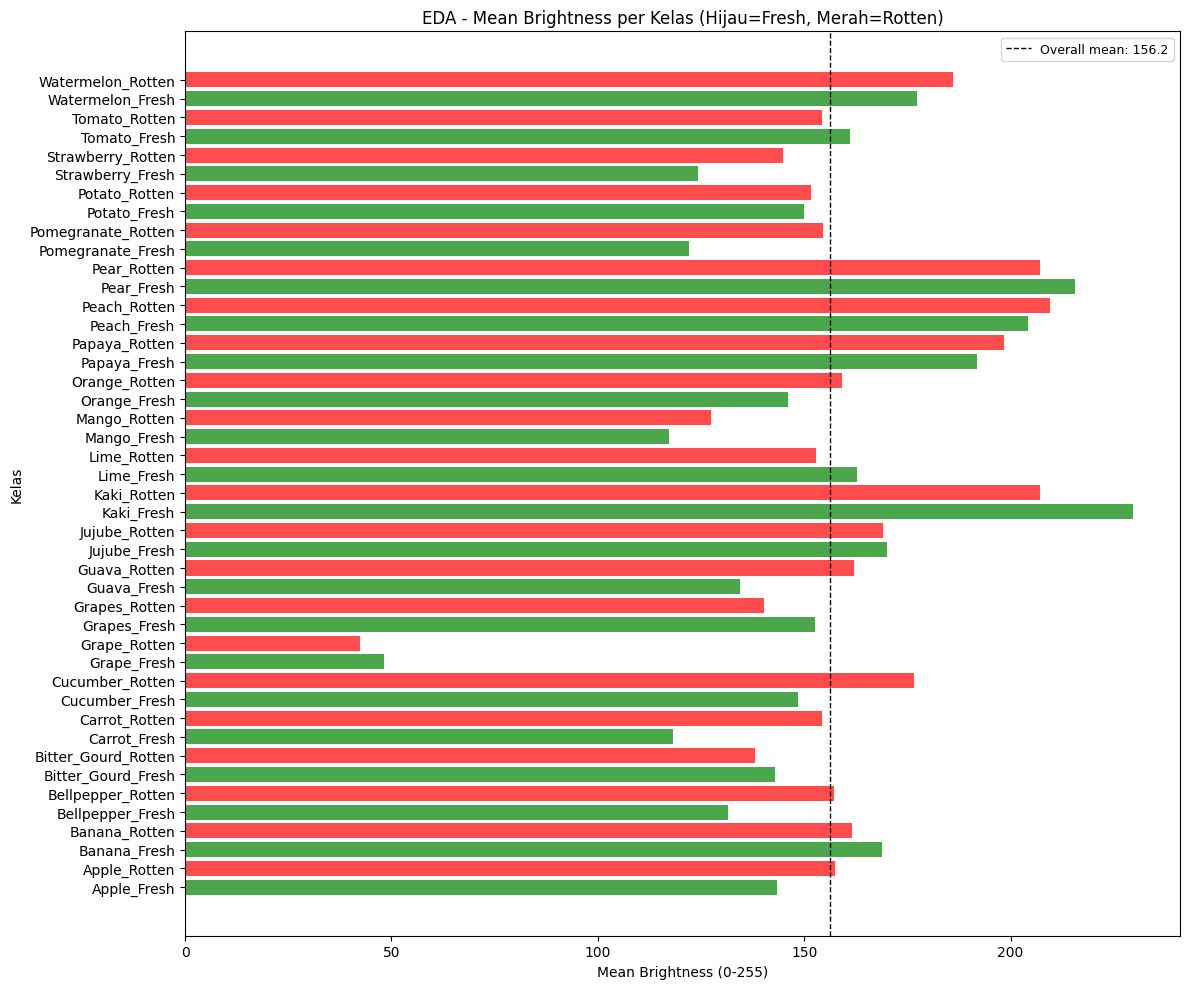

In [8]:
# Mean Brightness per Kelas
kelas_sorted   = sorted(mean_rgb_per_kelas.keys())
brightness_val = [np.mean(mean_rgb_per_kelas[k]) for k in kelas_sorted]
warna_bar      = ['green' if 'Fresh' in k else 'red' for k in kelas_sorted]

plt.figure(figsize=(12, 10))
bars = plt.barh(kelas_sorted, brightness_val, color=warna_bar, alpha=0.7)
plt.axvline(np.mean(brightness_val), color='black', linestyle='--', linewidth=1,
            label=f'Overall mean: {np.mean(brightness_val):.1f}')
plt.xlabel('Mean Brightness (0-255)')
plt.ylabel('Kelas')
plt.title('EDA - Mean Brightness per Kelas (Hijau=Fresh, Merah=Rotten)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

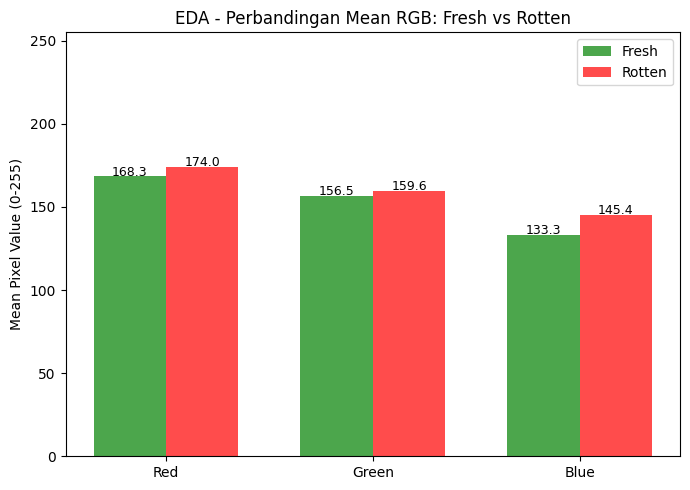

Ringkasan Mean RGB
  Red   — Fresh: 168.3  |  Rotten: 174.0  |  Selisih: 5.6
  Green — Fresh: 156.5  |  Rotten: 159.6  |  Selisih: 3.0
  Blue  — Fresh: 133.3  |  Rotten: 145.4  |  Selisih: 12.1


In [9]:
# Perbandingan Mean RGB Fresh vs Rotten (agregat)
fresh_r, fresh_g, fresh_b = [], [], []
rotten_r, rotten_g, rotten_b = [], [], []

for nama_kelas, (mr, mg, mb) in mean_rgb_per_kelas.items():
    if 'Fresh' in nama_kelas:
        fresh_r.append(mr); fresh_g.append(mg); fresh_b.append(mb)
    else:
        rotten_r.append(mr); rotten_g.append(mg); rotten_b.append(mb)

# Hitung mean agregat
label_channel = ['Red', 'Green', 'Blue']
fresh_means   = [np.mean(fresh_r),  np.mean(fresh_g),  np.mean(fresh_b)]
rotten_means  = [np.mean(rotten_r), np.mean(rotten_g), np.mean(rotten_b)]

x = np.arange(len(label_channel))
lebar = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - lebar/2, fresh_means,  lebar, label='Fresh',  color='green', alpha=0.7)
ax.bar(x + lebar/2, rotten_means, lebar, label='Rotten', color='red',   alpha=0.7)

# Tambahkan angka di atas setiap bar
for i, (fv, rv) in enumerate(zip(fresh_means, rotten_means)):
    ax.text(i - lebar/2, fv + 0.5, f'{fv:.1f}', ha='center', fontsize=9)
    ax.text(i + lebar/2, rv + 0.5, f'{rv:.1f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(label_channel)
ax.set_ylabel('Mean Pixel Value (0-255)')
ax.set_title('EDA - Perbandingan Mean RGB: Fresh vs Rotten')
ax.legend()
ax.set_ylim(0, 255)
plt.tight_layout()
plt.show()

# Print ringkasan numerik
print("Ringkasan Mean RGB")
for ch, fv, rv in zip(label_channel, fresh_means, rotten_means):
    print(f"  {ch:5s} — Fresh: {fv:.1f}  |  Rotten: {rv:.1f}  |  Selisih: {abs(fv-rv):.1f}")

## 3. Setup

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 4. Data Preprocessing & Splitting

In [12]:
# Augmentasi untuk data training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Augmentasi untuk data validasi & test
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [13]:
# Load dataset 3x dengan transform berbeda
dataset_for_train = datasets.ImageFolder(root=dataset_path, transform=train_transform)
dataset_for_val   = datasets.ImageFolder(root=dataset_path, transform=eval_transform)
dataset_for_test  = datasets.ImageFolder(root=dataset_path, transform=eval_transform)

# Jumlah kelas diambil secara dinamis, tidak hardcoded
jumlah_kelas = len(dataset_for_train.classes)
class_names = dataset_for_train.classes
targets = dataset_for_train.targets

print(f"Jumlah kelas: {jumlah_kelas}")
print(f"Nama kelas: {class_names}")

Jumlah kelas: 44
Nama kelas: ['Apple_Fresh', 'Apple_Rotten', 'Banana_Fresh', 'Banana_Rotten', 'Bellpepper_Fresh', 'Bellpepper_Rotten', 'Bitter_Gourd_Fresh', 'Bitter_Gourd_Rotten', 'Carrot_Fresh', 'Carrot_Rotten', 'Cucumber_Fresh', 'Cucumber_Rotten', 'Grape_Fresh', 'Grape_Rotten', 'Grapes_Fresh', 'Grapes_Rotten', 'Guava_Fresh', 'Guava_Rotten', 'Jujube_Fresh', 'Jujube_Rotten', 'Kaki_Fresh', 'Kaki_Rotten', 'Lime_Fresh', 'Lime_Rotten', 'Mango_Fresh', 'Mango_Rotten', 'Orange_Fresh', 'Orange_Rotten', 'Papaya_Fresh', 'Papaya_Rotten', 'Peach_Fresh', 'Peach_Rotten', 'Pear_Fresh', 'Pear_Rotten', 'Pomegranate_Fresh', 'Pomegranate_Rotten', 'Potato_Fresh', 'Potato_Rotten', 'Strawberry_Fresh', 'Strawberry_Rotten', 'Tomato_Fresh', 'Tomato_Rotten', 'Watermelon_Fresh', 'Watermelon_Rotten']


In [14]:
# STRATIFIED SPLIT (70/15/15)
# Langkah 1: Pisahkan train (70%) dan sisa (30%)
train_idx, temp_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.3,
    shuffle=True,
    stratify=targets,
    random_state=42
)

# Langkah 2: Pisahkan sisa (30%) menjadi val (15%) dan test (15%)
temp_targets = np.array(targets)[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    shuffle=True,
    stratify=temp_targets,
    random_state=42
)

# Buat Subset untuk masing-masing split
train_dataset = Subset(dataset_for_train, train_idx)
val_dataset   = Subset(dataset_for_val, val_idx)
test_dataset  = Subset(dataset_for_test, test_idx)

print(f"Jumlah data Training   : {len(train_dataset)} ({len(train_dataset)/len(targets)*100:.1f}%)")
print(f"Jumlah data Validation : {len(val_dataset)} ({len(val_dataset)/len(targets)*100:.1f}%)")
print(f"Jumlah data Testing    : {len(test_dataset)} ({len(test_dataset)/len(targets)*100:.1f}%)")
print(f"Total                  : {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Jumlah data Training   : 37531 (70.0%)
Jumlah data Validation : 8042 (15.0%)
Jumlah data Testing    : 8043 (15.0%)
Total                  : 53616


In [15]:
batch_size = 32
num_workers = 4 if device.type == 'cuda' else 0

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)

print(f"Batch size: {batch_size}")
print(f"Num workers: {num_workers}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 32
Num workers: 4
Train batches: 1173
Val batches: 252
Test batches: 252


## 5. Arsitektur Model

In [16]:
class FreshnessCNN(nn.Module):
    def __init__(self, num_classes):
        super(FreshnessCNN, self).__init__()
        
        # Blok Konvolusi 1: (3 x 224 x 224) -> (16 x 112 x 112)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        
        # Blok Konvolusi 2: (16 x 112 x 112) -> (32 x 56 x 56)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        
        # Blok Konvolusi 3: (32 x 56 x 56) -> (64 x 28 x 28)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        
        # Blok Konvolusi 4: (64 x 28 x 28) -> (128 x 14 x 14)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)
        
        # Blok Konvolusi 5: (128 x 14 x 14) -> (256 x 7 x 7)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(256)
        
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Urutan: Conv -> BatchNorm -> ReLU -> MaxPool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Inisialisasi model dengan jumlah kelas dinamis
model = FreshnessCNN(num_classes=jumlah_kelas).to(device)

# Hitung total parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameter: {total_params:,}")
print(f"Trainable parameter: {trainable_params:,}")
print(f"\nArsitektur model:\n{model}")

Total parameter: 6,839,212
Trainable parameter: 6,839,212

Arsitektur model:
FreshnessCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

## 6. Loss Function, Optimizer, & Scheduler

In [17]:
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [18]:
# Class weights untuk menangani imbalance
class_counts = np.bincount(targets)
class_weights = len(targets) / (jumlah_kelas * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss function
criterion = FocalLoss(weight=weights_tensor, gamma=2.0)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning Rate Scheduler (turunkan LR jika val loss stuck selama 3 epoch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"Loss: FocalLoss (gamma=2.0) with class weights")

Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
Loss: FocalLoss (gamma=2.0) with class weights


## 7. Training

In [ ]:
# Early Stopping class + History Logging
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"  >> EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [ ]:
epochs = 100 
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_state = None
start_time = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    
    # FASE TRAINING
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train * 100
    
    # FASE VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val * 100
    
    # Catat current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Simpan history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Simpan best model berdasarkan val accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        save_marker = ' << BEST'
    else:
        save_marker = ''
    
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch [{epoch+1:2d}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s{save_marker}")
    
    # LR Scheduler step berdasarkan val loss
    scheduler.step(val_loss)
    
    # Early stopping check
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"\n>> Early stopping triggered pada epoch {epoch+1}!")
        break

total_time = time.time() - start_time
print(f"\nTraining selesai dalam {total_time:.1f} detik ({total_time/60:.1f} menit)")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch [ 1/100] | Train Loss: 3.1258 | Train Acc: 4.40% | Val Loss: 2.6481 | Val Acc: 7.76% | LR: 0.001000 | Time: 242.6s << BEST
Epoch [ 2/100] | Train Loss: 2.6148 | Train Acc: 7.66% | Val Loss: 1.8313 | Val Acc: 16.35% | LR: 0.001000 | Time: 146.4s << BEST
Epoch [ 3/100] | Train Loss: 2.3033 | Train Acc: 10.39% | Val Loss: 1.7014 | Val Acc: 17.21% | LR: 0.001000 | Time: 136.5s << BEST
Epoch [ 4/100] | Train Loss: 1.9555 | Train Acc: 14.20% | Val Loss: 1.2534 | Val Acc: 27.85% | LR: 0.001000 | Time: 174.8s << BEST
Epoch [ 5/100] | Train Loss: 1.7372 | Train Acc: 17.98% | Val Loss: 1.0089 | Val Acc: 32.55% | LR: 0.001000 | Time: 173.0s << BEST
Epoch [ 6/100] | Train Loss: 1.5512 | Train Acc: 21.29% | Val Loss: 0.8833 | Val Acc: 31.80% | LR: 0.001000 | Time: 156.4s
Epoch [ 7/100] | Train Loss: 1.3464 | Train Acc: 25.69% | Val Loss: 0.7739 | Val Acc: 39.99% | LR: 0.001000 | Time: 133.7s << BEST
Epoch [ 8/100] | Train Loss: 1.1680 | Train Acc: 31.09% | Val Loss: 0.6924 | Val Acc: 47.96% |

In [ ]:
# # Simpan best model
# torch.save(best_model_state, 'model_freshness_cnn_update.pth')
# print("Best model berhasil disimpan ke 'model_freshness_cnn_update.pth'")

# Load best model untuk evaluasi
model.load_state_dict(best_model_state)
print("Best model berhasil di-load untuk evaluasi.")

Best model berhasil disimpan ke 'model_freshness_cnn_update.pth'
Best model berhasil di-load untuk evaluasi.


## 8. Visualisasi

In [19]:
# Load model tanpa train ulang
model = FreshnessCNN(num_classes=jumlah_kelas).to(device)
model.load_state_dict(torch.load('model_freshness_cnn_final.pth', map_location=device))
model.eval()

FreshnessCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_featu

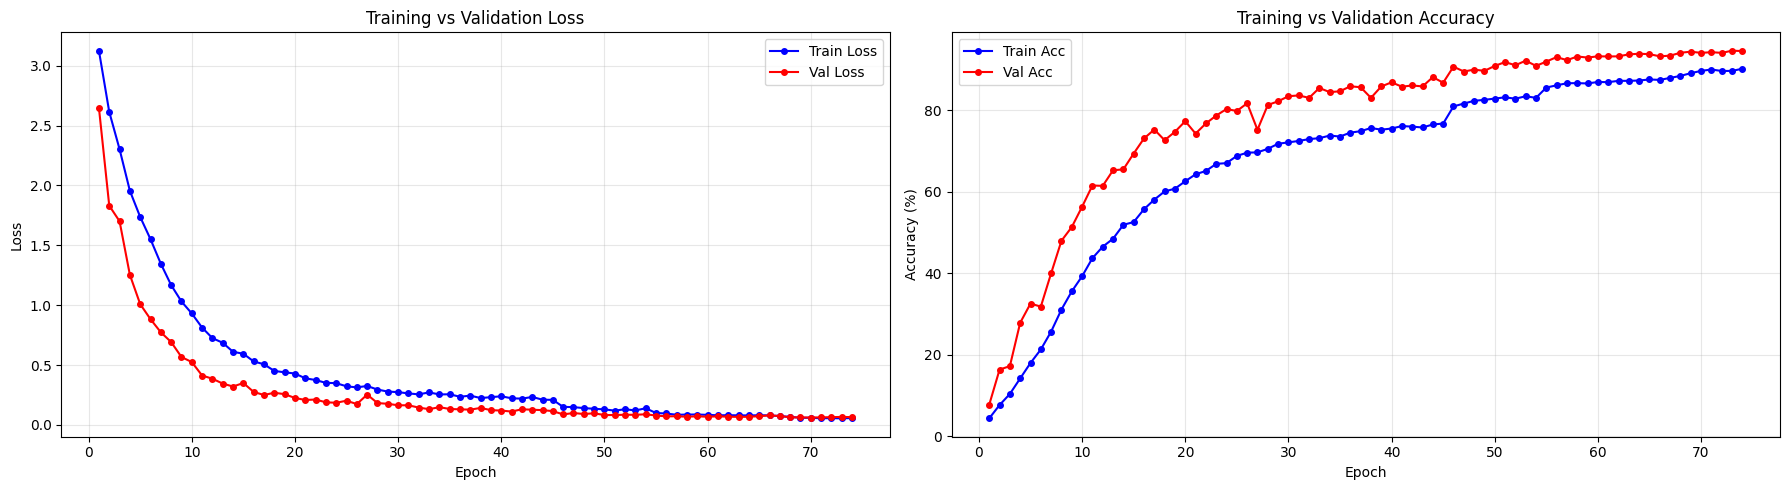

Plot disimpan ke 'training_history_baseline.png'


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
epoch_range = range(1, len(history['train_loss']) + 1)

# Plot 1: Loss
axes[0].plot(epoch_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epoch_range, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(epoch_range, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epoch_range, history['val_acc'], 'r-o', markersize=4, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan ke 'training_history_baseline.png'")

## 9. Evaluasi pada Test Set

In [22]:
# Evaluasi pada TEST set
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Test accuracy
test_acc = (all_preds == all_labels).sum() / len(all_labels) * 100
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 95.04%


In [23]:
# Classification Report
print("CLASSIFICATION REPORT (Test Set)")
report = classification_report(
    all_labels, all_preds, target_names=class_names, zero_division=0
)
print(report)

CLASSIFICATION REPORT (Test Set)
                     precision    recall  f1-score   support

        Apple_Fresh       0.93      0.91      0.92       520
       Apple_Rotten       0.95      0.89      0.92       640
       Banana_Fresh       0.99      0.96      0.97       527
      Banana_Rotten       0.98      0.95      0.97       541
   Bellpepper_Fresh       0.95      0.98      0.96       245
  Bellpepper_Rotten       0.90      0.90      0.90       316
 Bitter_Gourd_Fresh       1.00      1.00      1.00        49
Bitter_Gourd_Rotten       1.00      1.00      1.00        53
       Carrot_Fresh       0.99      0.88      0.93        91
      Carrot_Rotten       0.66      0.89      0.76        76
     Cucumber_Fresh       0.93      0.99      0.96       125
    Cucumber_Rotten       0.95      0.91      0.93       104
        Grape_Fresh       1.00      1.00      1.00        34
       Grape_Rotten       1.00      1.00      1.00        43
       Grapes_Fresh       0.91      1.00      0.95 

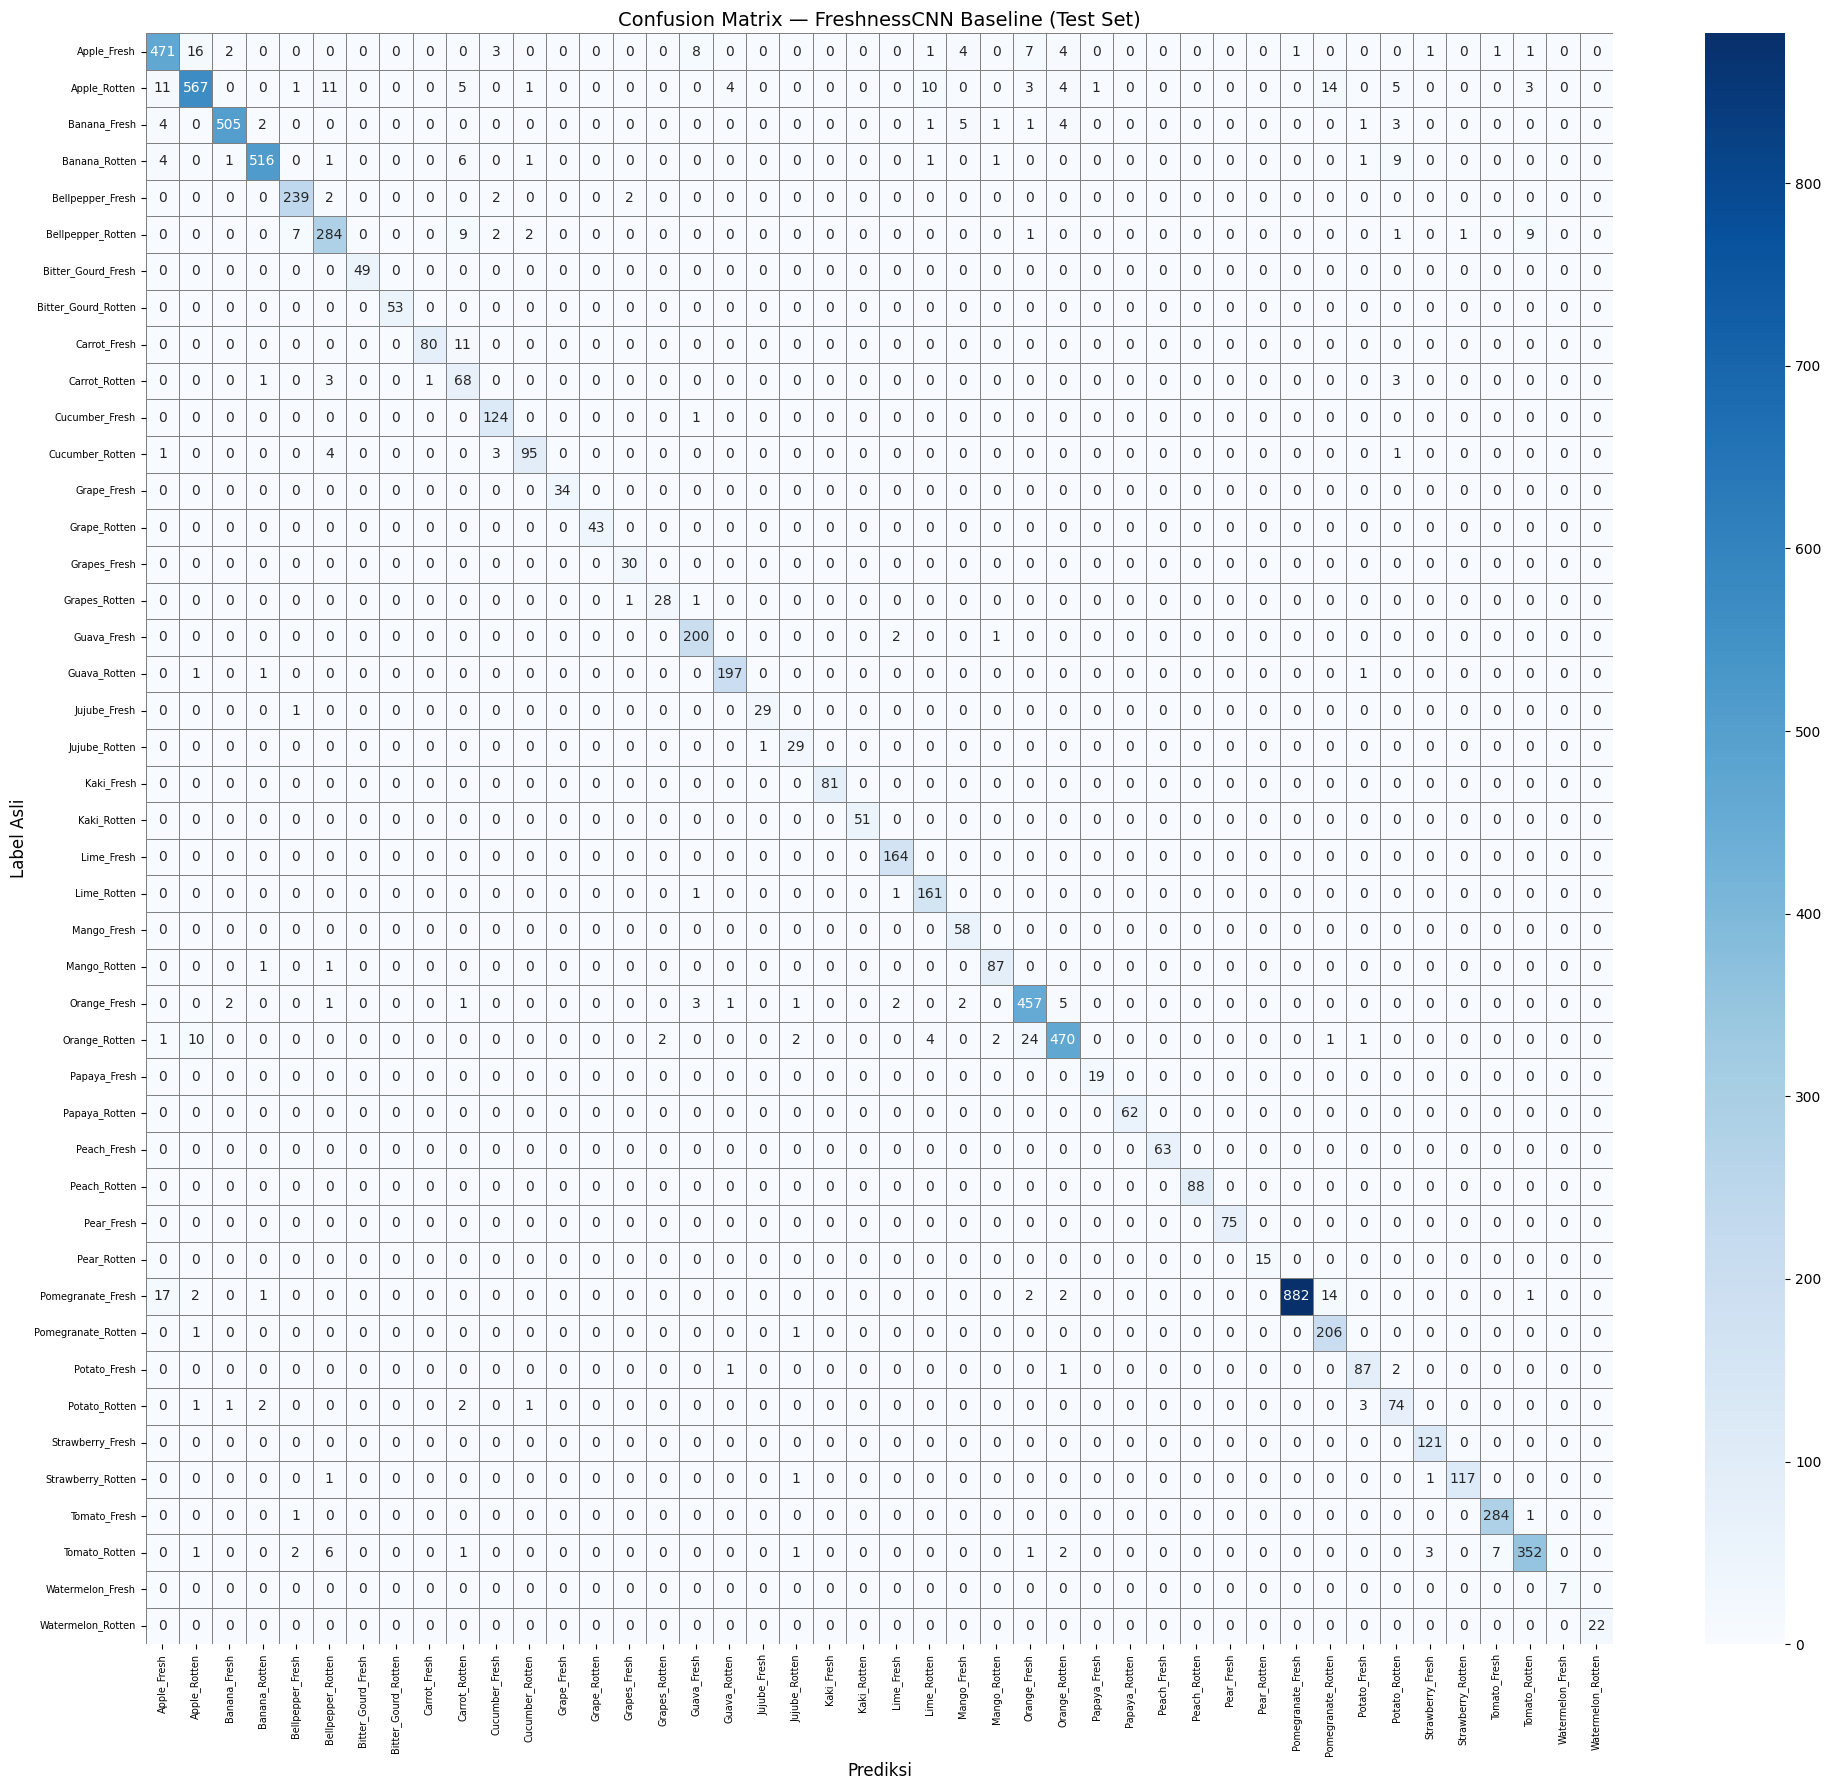

Confusion matrix disimpan ke 'confusion_matrix_baseline.png'


In [24]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='gray'
)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Label Asli', fontsize=12)
plt.title('Confusion Matrix — FreshnessCNN Baseline (Test Set)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan ke 'confusion_matrix_baseline.png'")

## 10. Error Analysis

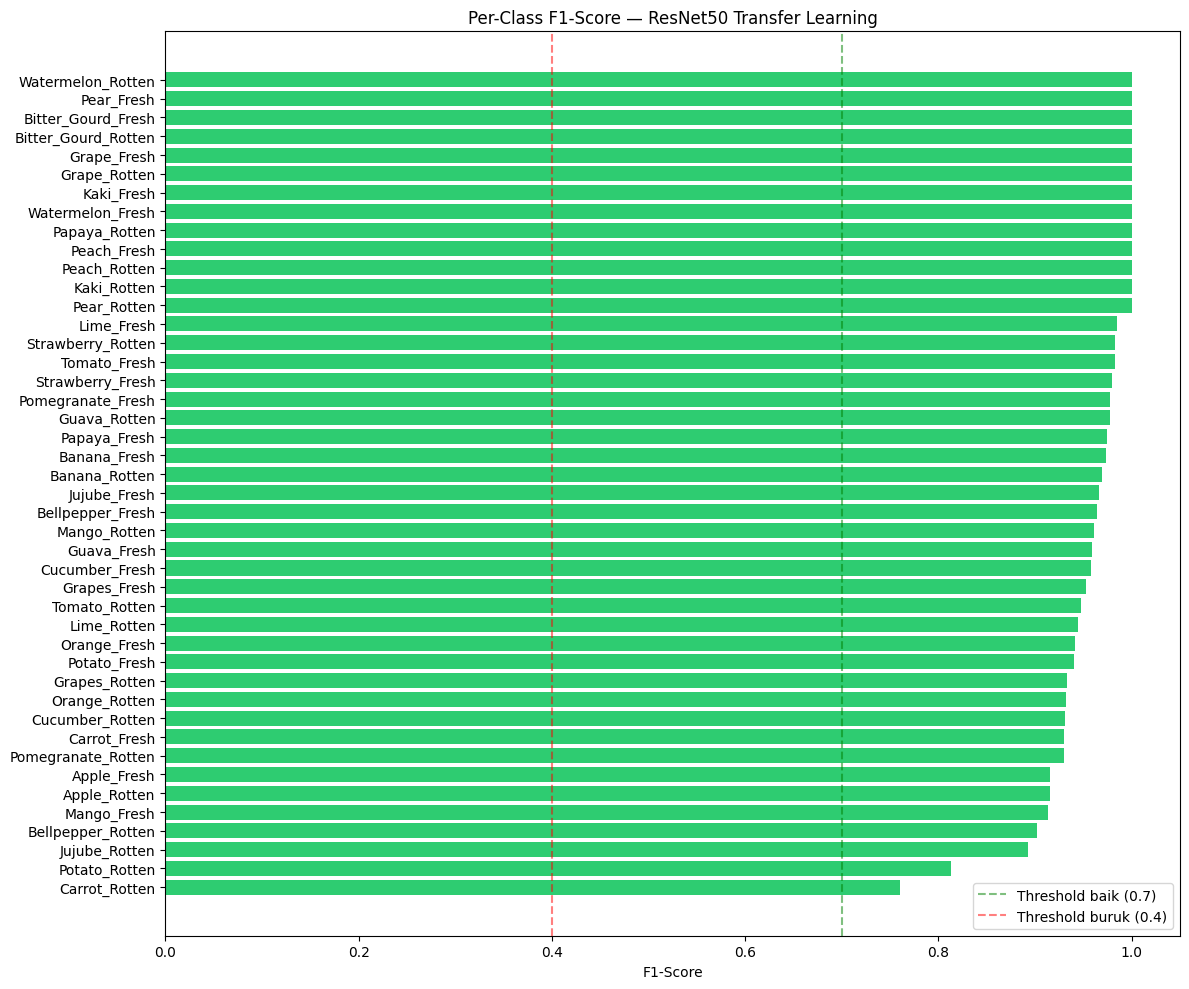

In [25]:
report_dict = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    output_dict=True
)

# Buat dict class_name -> f1-score
class_f1 = {name: report_dict[name]['f1-score'] for name in class_names}

# Visualisasi: Per-class F1-score — SAMA format dengan baseline
f1_scores = [class_f1[name] for name in class_names]
sorted_idx = np.argsort(f1_scores)
sorted_names = [class_names[i] for i in sorted_idx]
sorted_f1 = [f1_scores[i] for i in sorted_idx]

colors = ['#e74c3c' if f1 < 0.4 else '#f39c12' if f1 < 0.7 else '#2ecc71' for f1 in sorted_f1]

plt.figure(figsize=(12, 10))
plt.barh(sorted_names, sorted_f1, color=colors)
plt.xlabel('F1-Score')
plt.title('Per-Class F1-Score — ResNet50 Transfer Learning')
plt.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Threshold baik (0.7)')
plt.axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='Threshold buruk (0.4)')
plt.legend()
plt.tight_layout()
plt.savefig('per_class_f1_resnet50_tl.png', dpi=150, bbox_inches='tight')
plt.show()

# Test

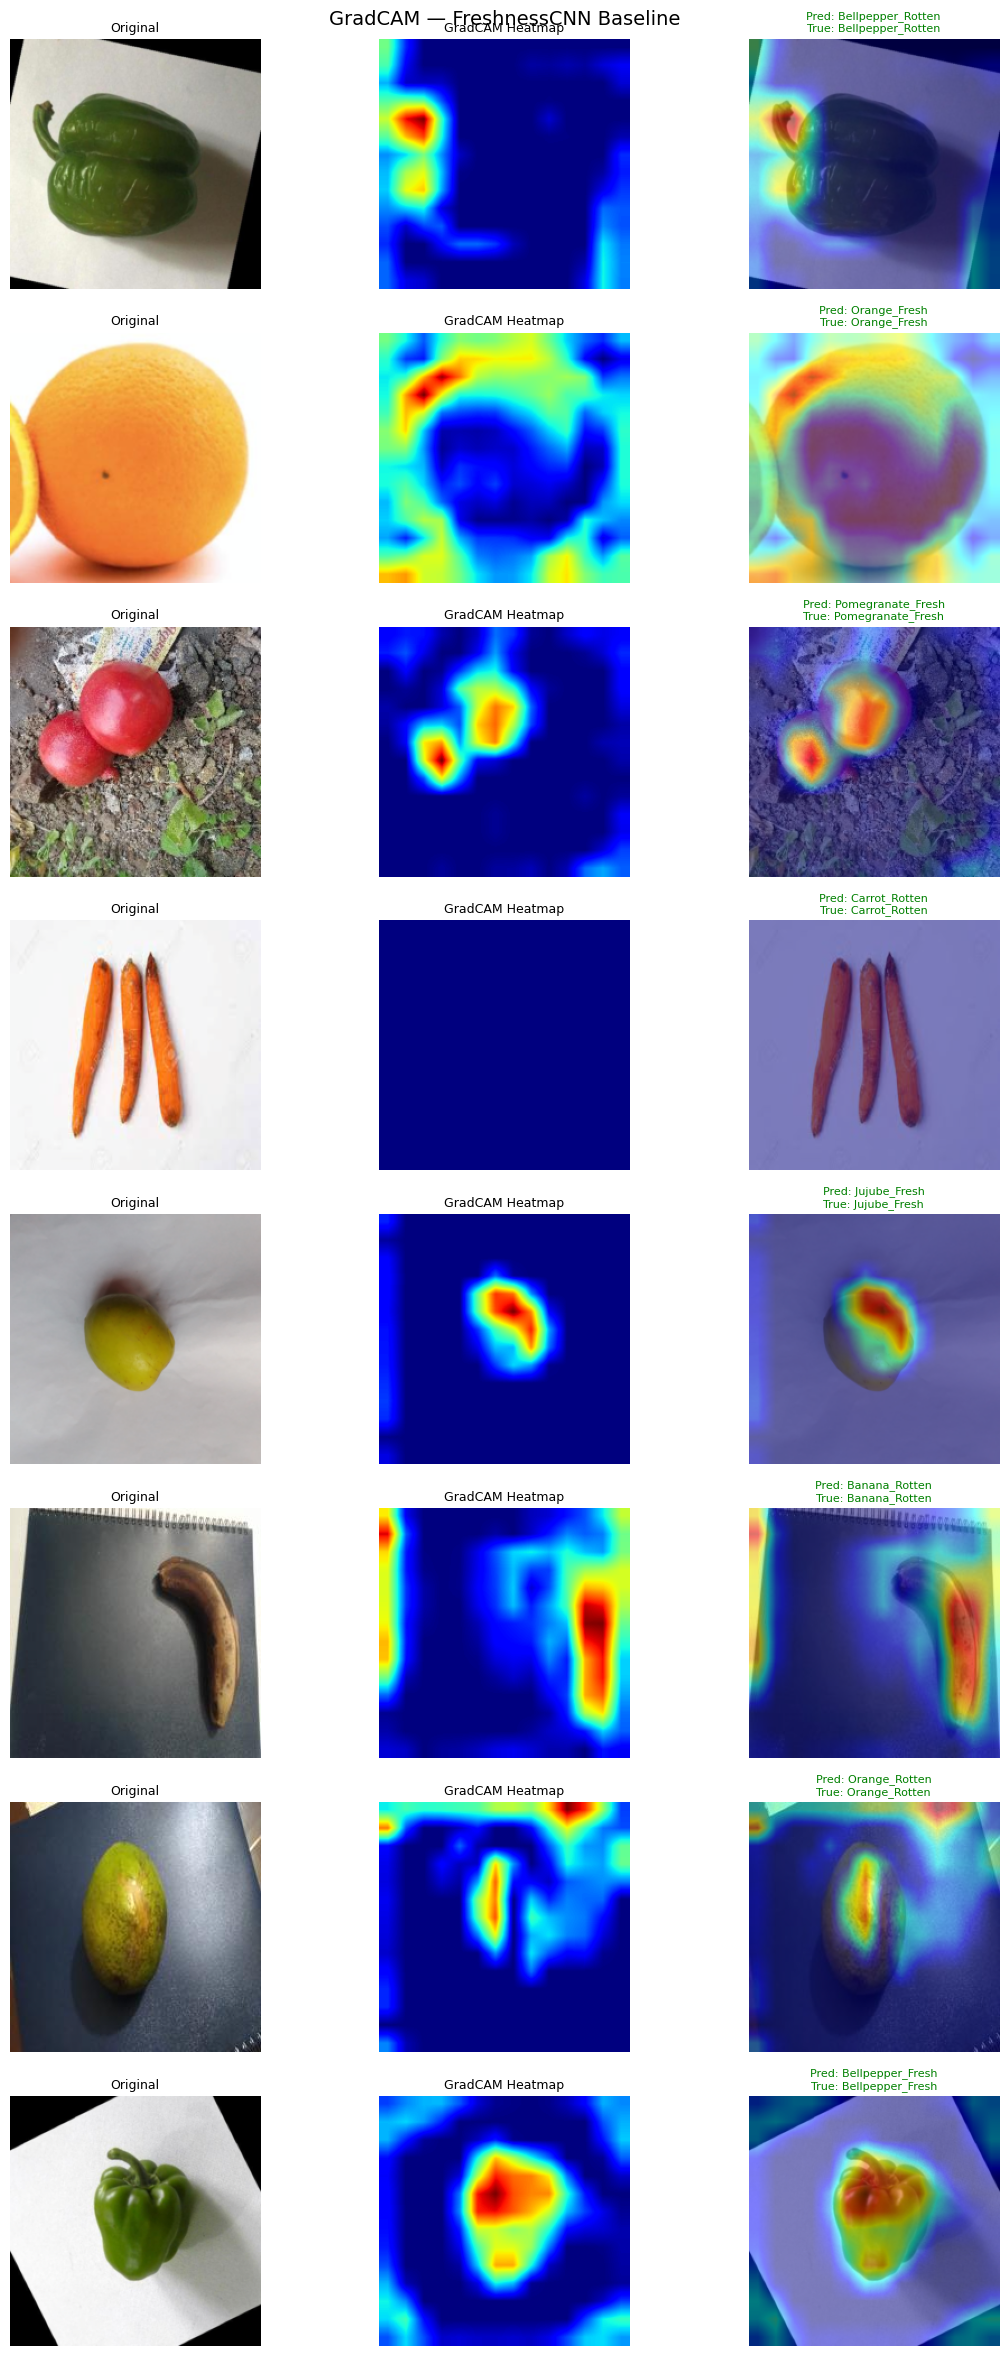

In [27]:
# --- GradCAM untuk FreshnessCNN ---
import cv2

model_gradcam = FreshnessCNN(num_classes=jumlah_kelas).to(device)
model_gradcam.load_state_dict(torch.load('model_freshness_cnn_final.pth', map_location=device))
model_gradcam.eval()

gradients = []
activations = []

def save_gradient(grad):
    gradients.append(grad)

def forward_hook(module, input, output):
    activations.append(output)
    output.register_hook(save_gradient)

hook = model_gradcam.conv5.register_forward_hook(forward_hook)

def generate_gradcam(img_tensor, class_idx=None):
    gradients.clear()
    activations.clear()
    
    img_tensor = img_tensor.unsqueeze(0).to(device)
    output = model_gradcam(img_tensor)
    
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()
    
    model_gradcam.zero_grad()
    output[0, class_idx].backward()
    
    grad = gradients[0].squeeze(0)
    act  = activations[0].squeeze(0)
    weights = grad.mean(dim=(1, 2))
    
    cam = torch.zeros(act.shape[1:], device=device)
    for i, w in enumerate(weights):
        cam += w * act[i]
    
    cam = F.relu(cam)
    cam = cam.detach().cpu().numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)
    img  = img * std + mean
    return np.clip(img, 0, 1)

n_samples = 8
sample_indices = np.random.choice(len(test_dataset), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))
fig.suptitle('GradCAM — FreshnessCNN Baseline', fontsize=14)

for i, idx in enumerate(sample_indices):
    img_tensor, true_label = test_dataset[idx]
    
    cam, pred_idx = generate_gradcam(img_tensor)
    img_np = denormalize(img_tensor)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    pred_label = class_names[pred_idx]
    true_label_name = class_names[true_label]
    color = 'green' if pred_idx == true_label else 'red'
    
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title('Original', fontsize=9)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam, cmap='jet')
    axes[i, 1].set_title('GradCAM Heatmap', fontsize=9)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f'Pred: {pred_label}\nTrue: {true_label_name}', fontsize=8, color=color)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

hook.remove()